# Dataset is Customer Churn Prediction:
* Churn refers to the rate at which customers stop doing business with a company over a given period.
* In customer churn prediction, the goal is to identify which customers are likely to leave (churn) in the future based on historical data.


Import dataset from Kaggle-Drive.

In [2]:
import pandas as pd
df = pd.read_csv(r'C:\Rishikha\Projects\Customer_Churn_Prediction\customer_churn_dataset-testing-master.csv')

Displaying first 5 rows of the dataset.

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


Displaying shape, columns, and type of the data.

In [4]:
print(df.shape)
print(df.columns)
print(type(df))

(64374, 12)
Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>


* CustomerID - Unique identifier for each customer.
* Age - The age of the customer. Helps identify if specific age demographics are more likely to churn.
* Gender - The gender of the customer.
* Tenure - The number of months the customer has been with the company. Long-term customers usually have higher loyalty.
* Usage Frequency - How often the customer uses the service (e.g., sessions per month). Low usage is a leading indicator of churn.
* Support Calls - The number of times a customer contacted customer service. High frequency often indicates unresolved dissatisfaction.
* Payment Delay - The average number of days a customer’s payment is overdue. Financial friction is a strong churn predictor.
* Subscription Type - The level of service (Basic, Standard, Premium). Analyzed to see if specific plans have higher attrition.
* Contract Length - The duration of the service agreement (Monthly, Quarterly, Annual). Shorter contracts often churn faster.
* Total Spend - The cumulative amount of money the customer has spent on the service.
* Last Interaction - Number of days since the customer last engaged with the service or support.
* Churn (Target) - The dependent variable indicating whether the customer left (1) or stayed (0).

# Data Preprocessing

Removing Unnecessary Columns:
1. CustomerID
2. Contract Length
3. Gender

In [5]:
df.drop(['CustomerID', 'Contract Length', 'Gender'], axis = 1, inplace = True)

Converting categorical features into numerical form.

In [6]:
df = pd.get_dummies(df, columns=["Subscription Type"], drop_first=True)
# one-hot encoding- converted string into numerical binary values(1 and 0).

In [7]:
df.dtypes

Age                           int64
Tenure                        int64
Usage Frequency               int64
Support Calls                 int64
Payment Delay                 int64
Total Spend                   int64
Last Interaction              int64
Churn                         int64
Subscription Type_Premium      bool
Subscription Type_Standard     bool
dtype: object

In [8]:
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription Type_Premium,Subscription Type_Standard
0,22,25,14,4,27,598,9,1,False,False
1,41,28,28,7,13,584,20,0,False,True
2,47,27,10,2,29,757,21,0,True,False
3,35,9,12,5,17,232,18,0,True,False
4,53,58,24,9,2,533,18,0,False,True


Check if the dataset has duplicate values.

In [9]:
df.duplicated().sum()

np.int64(0)

Checking for null values

In [10]:
df.isna().sum()

Age                           0
Tenure                        0
Usage Frequency               0
Support Calls                 0
Payment Delay                 0
Total Spend                   0
Last Interaction              0
Churn                         0
Subscription Type_Premium     0
Subscription Type_Standard    0
dtype: int64

Checking for unique values in each columns.

In [11]:
df.nunique()

Age                            48
Tenure                         60
Usage Frequency                30
Support Calls                  11
Payment Delay                  31
Total Spend                   901
Last Interaction               30
Churn                           2
Subscription Type_Premium       2
Subscription Type_Standard      2
dtype: int64

Checking if dataset is imbalanced.

In [12]:
print(df["Churn"].value_counts())

Churn
0    33881
1    30493
Name: count, dtype: int64


# Data Normalization using StandardScaler
* We didn't use MinMaxScaler because it is sensitive to outliers since it depends on min/max values.

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ["Age", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay", "Total Spend", "Last Interaction"]
df[num_cols] = scaler.fit_transform(df[num_cols])

Get descriptive statistics for numerical columns.

In [14]:
df[num_cols].describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
count,6.437400e+04,6.437400e+04,6.437400e+04,6.437400e+04,6.437400e+04,6.437400e+04,6.437400e+04
mean,-1.766037e-16,-9.889805e-17,6.004524e-17,-1.412829e-16,-1.271546e-16,-5.651317e-17,4.437167e-17
std,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00
min,-1.721459e+00,-1.812764e+00,-1.597050e+00,-1.734336e+00,-1.935571e+00,-1.690569e+00,-1.678425e+00
25%,-8.596877e-01,-8.185018e-01,-9.165002e-01,-7.709392e-01,-8.059011e-01,-8.740788e-01,-8.680864e-01
50%,2.083902e-03,5.878857e-02,-9.100567e-03,1.924579e-01,2.108019e-01,-2.692262e-02,-5.774822e-02
75%,8.638555e-01,8.775929e-01,8.982991e-01,8.347227e-01,8.886039e-01,8.700663e-01,8.683525e-01
max,1.653813e+00,1.637911e+00,1.692274e+00,1.476987e+00,1.453439e+00,1.759389e+00,1.678691e+00


# Data Visualization

 Visualize the correlation matrix for numerical features.


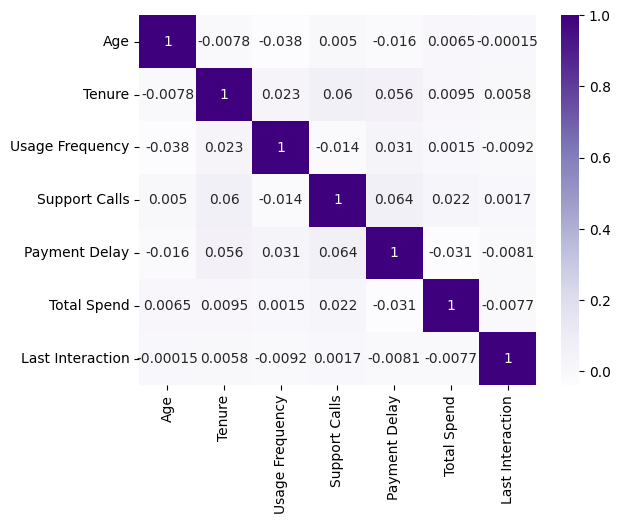

In [15]:
import seaborn as sb
import matplotlib.pyplot as plt
cm=df[num_cols].corr()
sb.heatmap(cm, annot=True, cmap='Purples') #annot=used to show number
plt.show()

Distribution of Churn and No-Churn using a pie chart.


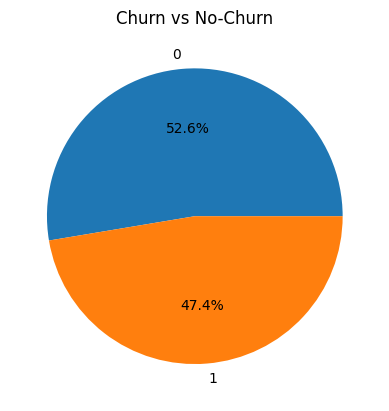

In [16]:
x = df['Churn'].value_counts()
plt.pie(x.values, labels=x.index, autopct='%1.1f%%')
plt.title('Churn vs No-Churn')
plt.show()

In [17]:
x = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type_Premium',
       'Subscription Type_Standard', 'Total Spend', 'Last Interaction']
y = 'Churn'

Splitting the dataset into train and test data.

In [18]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(df[x], df[y], test_size=0.2, random_state=42)
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(51499, 9)
(12875, 9)
(51499,)
(12875,)


Fitting the data into logistic regression model.

In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(xtrain, ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Evaluating the model's performance using accuracy score and confusion matrix.

In [20]:
from sklearn.metrics import accuracy_score
ypred = model.predict(xtest)
acc_score = accuracy_score(ytest, ypred) * 100
print(f"Accuracy Score: {acc_score:.2f}")

Accuracy Score: 81.90


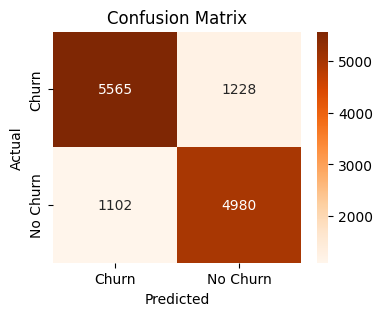

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 3))
cm = confusion_matrix(ytest, ypred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["Churn", "No Churn"], yticklabels=["Churn", "No Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Comparing train and test accuracy.

In [22]:
ypredtrain = model.predict(xtrain)
print('Train accuracy: ',accuracy_score(ypredtrain, ytrain) * 100)
print('Test accuracy: ',accuracy_score(ypred, ytest) * 100)

Train accuracy:  81.00157284607468
Test accuracy:  81.90291262135922


**Ensemble methods:**
* Bagging using RandomForestClassifier.
* Ensemble methods are used for improving predictive performance of models.

In [23]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
model = BaggingClassifier(estimator = RandomForestClassifier(), n_estimators = 5, random_state = 40)
model.fit(xtrain, ytrain)

,estimator,RandomForestClassifier()
,n_estimators,5
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,40
,verbose,0


In [24]:
ypreds = model.predict(xtest)
rf_acc_score = accuracy_score(ytest, ypreds) * 100
print(rf_acc_score)

92.36504854368933


Comparing test accuracies between Logistic Regression and Random Forest.

In [25]:
print("Accuracy Comparison:")
print(f"Logistic Regression: {acc_score:.4f}")
print(f"Random Forest (Ensemble): {rf_acc_score:.4f}")

Accuracy Comparison:
Logistic Regression: 81.9029
Random Forest (Ensemble): 92.3650


Prediction with sample data.

In [50]:
import pandas as pd
import numpy as np

def predict_churn(customer_data):
    input_df = pd.DataFrame([customer_data])

    input_df['Subscription Type_Premium'] = 1 if customer_data.get('Subscription Type') == 'Premium' else 0
    input_df['Subscription Type_Standard'] = 1 if customer_data.get('Subscription Type') == 'Standard' else 0
    
    feature_order = [
        'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 
        'Subscription Type_Premium', 'Subscription Type_Standard', 
        'Total Spend', 'Last Interaction'
    ]
    
    num_cols = ["Age", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay", "Total Spend", "Last Interaction"]

    input_df[num_cols] = scaler.transform(input_df[num_cols])

    final_input = input_df[feature_order]

    prediction = model.predict(final_input)[0]
    probability = model.predict_proba(final_input)[0][1]

    result = "CHURN (Likely to leave)" if prediction == 1 else "STAY (Likely to remain)"
    return f"Result: {result} | Risk Probability: {probability:.2%}"

example_customer = {
    'Age': 45,
    'Tenure': 12,
    'Usage Frequency': 5,
    'Support Calls': 8,      
    'Payment Delay': 20,     
    'Subscription Type': 'Standard',
    'Total Spend': 500,
    'Last Interaction': 25
}

print(predict_churn(example_customer))

Result: STAY (Likely to remain) | Risk Probability: 10.20%


In [51]:
example2_customer = {
    'Age': 22,
    'Tenure': 3,              
    'Usage Frequency': 2,      
    'Support Calls': 10,       
    'Payment Delay': 28,       
    'Subscription Type': 'Basic', 
    'Total Spend': 100,        
    'Last Interaction': 30     
}

print(predict_churn(example2_customer))

Result: CHURN (Likely to leave) | Risk Probability: 77.40%
